In [2]:
import re
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yt
import SrcPython as sr

In [3]:
import os
import numpy as np
import pandas as pd
import yt

# ======================== CONFIGURATION ========================
root_reference = "/home/fernando/FPCE/PeleC/Exec/RegTests/1DFlame/ANALYSIS"
root_simulation = "RESULTS"
ref_file = "pltADV_01000"
sim_file = "pltADV_CLEM_01000"

X_MIN, X_MAX = 0.0, 1.5   # range of interest

# ======================== EXTRACTION FUNCTION ========================
def extract_fields(path):
    yt.set_log_level(50)
    ds = yt.load(path)
    c = ds.domain_center
    ray = ds.ortho_ray(0, (c[1], c[2]))
    order = np.argsort(ray["boxlib", "x"])
    
    x = np.array(ray["boxlib", "x"][order])
    density = np.array(ray["boxlib", "density"][order])
    xmom = np.array(ray["boxlib", "xmom"][order])
    velocity = np.array(ray["velocity_x"][order])
    pressure = np.array(ray["pressure"][order])
    rho_e = np.array(ray["rho_e"][order])
    # pressure = np.array(ray["boxlib", "pressure"][order])  # if needed
    
    return x, density, xmom, velocity, pressure, rho_e

# ======================== LOAD & INTERPOLATE ========================
ref_path = os.path.join(root_reference, ref_file)
sim_path = os.path.join(root_simulation, sim_file)

print(f"Reference: {ref_path}")
print(f"Simulation: {sim_path}")

x_ref, rho_ref, xmom_ref, vel_ref, p_ref, rhoe_ref = extract_fields(ref_path)
x_sim, rho_sim, xmom_sim, vel_sim, p_sim, rhoe_sim = extract_fields(sim_path)

# Interpolate simulation onto the reference grid
rho_sim_interp = np.interp(x_ref, x_sim, rho_sim)
xmom_sim_interp = np.interp(x_ref, x_sim, xmom_sim)
vel_sim_interp = np.interp(x_ref, x_sim, vel_sim)

# ======================== FILTER X-RANGE ========================
mask = (x_ref >= X_MIN) & (x_ref <= X_MAX)
x_filtered = x_ref[mask]
rho_err = rho_sim_interp[mask] - rho_ref[mask]
xmom_err = xmom_sim_interp[mask] - xmom_ref[mask]
vel_err = vel_sim_interp[mask] - vel_ref[mask]

plt.plot(x_sim, vel_sim[mask], label = "CLEM")
plt.plot(x_ref, vel_ref[mask], label = "REF")
plt.legend()
# ======================== BUILD TABLE ========================
df_errors = pd.DataFrame({
    "x": x_filtered,
    "error_density": rho_err,
    "error_xmom": xmom_err,
    "error_velocity": vel_err
})

# ======================== PRINT ========================
"""
print("\n" + "="*80)
print(f"Errors (sim − ref) in x ∈ [{X_MIN}, {X_MAX}] for step 01000")
print("="*80)
print(df_errors.to_string(index=False, float_format="%.6e"))
print("="*80)"""


Reference: /home/fernando/FPCE/PeleC/Exec/RegTests/1DFlame/ANALYSIS/pltADV_01000
Simulation: RESULTS/pltADV_CLEM_01000


/home/fernando/miniconda3/envs/fpce/lib/python3.11/site-packages/yt/sample_data/api.py:150: UserWarning: Storage directory from yt config doesn't exist (currently set to '/does/not/exist'). Current working directory will be used instead.
  warn(


FileNotFoundError: No such file or directory: 'RESULTS/pltADV_CLEM_01000'.

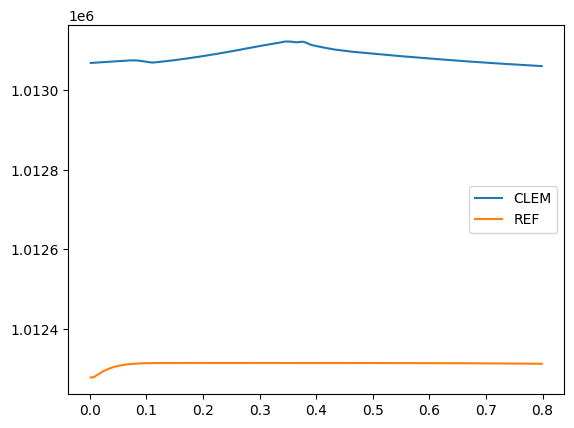

In [18]:
plt.plot(x_sim, p_sim[mask], label = "CLEM")
plt.plot(x_ref, p_ref[mask], label = "REF")
plt.legend()

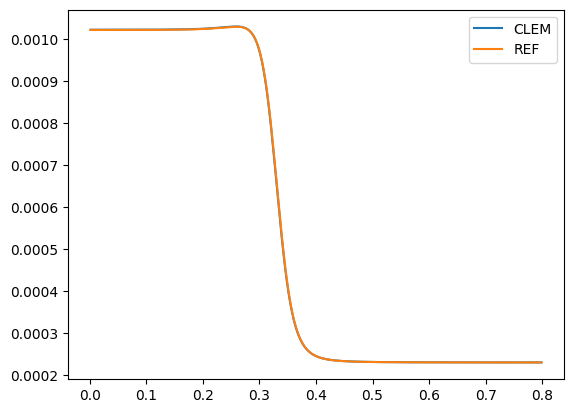

In [19]:
plt.plot(x_sim, rho_sim[mask], label = "CLEM")
plt.plot(x_ref, rho_ref[mask], label = "REF")
plt.legend()

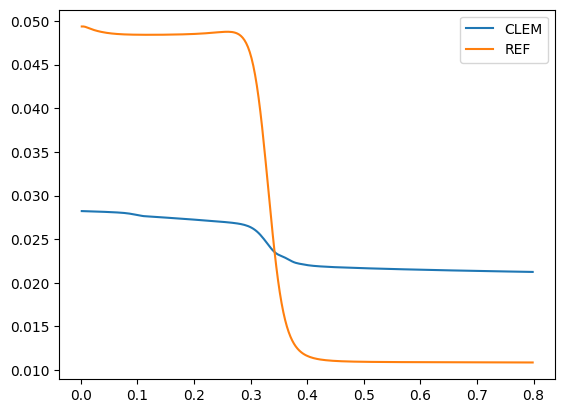

In [20]:
plt.plot(x_sim, xmom_sim[mask], label = "CLEM")
plt.plot(x_ref, xmom_ref[mask], label = "REF")
plt.legend()

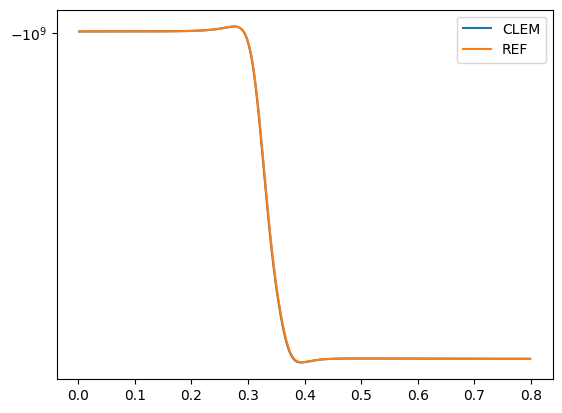

In [21]:
plt.plot(x_sim, rhoe_sim[mask]/rho_sim, label = "CLEM")
plt.plot(x_ref, rhoe_ref[mask]/rho_ref, label = "REF")
plt.legend()
plt.yscale("symlog")

Reference: /home/fernando/FPCE/PeleC/Exec/RegTests/1DFlame/ANALYSIS/pltDIF_01000
Simulation: RESULTS/pltDIF_CLEM_01000


'\nprint("\n" + "="*80)\nprint(f"Errors (sim − ref) in x ∈ [{X_MIN}, {X_MAX}] for step 01000")\nprint("="*80)\nprint(df_errors.to_string(index=False, float_format="%.6e"))\nprint("="*80)'

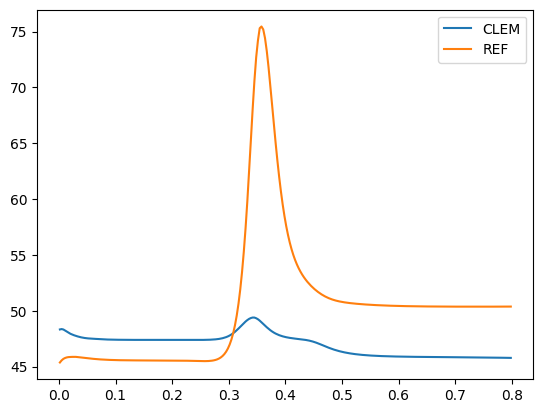

In [24]:
# ======================== CONFIGURATION ========================
root_reference = "/home/fernando/FPCE/PeleC/Exec/RegTests/1DFlame/ANALYSIS"
root_simulation = "RESULTS"
ref_file = "pltDIF_01000"
sim_file = "pltDIF_CLEM_01000"

X_MIN, X_MAX = 0.0, 1.5   # range of interest

# ======================== EXTRACTION FUNCTION ========================
def extract_fields(path):
    yt.set_log_level(50)
    ds = yt.load(path)
    c = ds.domain_center
    ray = ds.ortho_ray(0, (c[1], c[2]))
    order = np.argsort(ray["boxlib", "x"])
    
    x = np.array(ray["boxlib", "x"][order])
    density = np.array(ray["boxlib", "density"][order])
    xmom = np.array(ray["boxlib", "xmom"][order])
    velocity = np.array(ray["velocity_x"][order])
    pressure = np.array(ray["pressure"][order])
    temp = np.array(ray["Temp"][order])
    # pressure = np.array(ray["boxlib", "pressure"][order])  # if needed
    
    return x, density, xmom, velocity, pressure, temp

# ======================== LOAD & INTERPOLATE ========================
ref_path = os.path.join(root_reference, ref_file)
sim_path = os.path.join(root_simulation, sim_file)

print(f"Reference: {ref_path}")
print(f"Simulation: {sim_path}")

x_ref, rho_ref, xmom_ref, vel_ref, p_ref, temp_ref = extract_fields(ref_path)
x_sim, rho_sim, xmom_sim, vel_sim, p_sim, temp_sim = extract_fields(sim_path)

# Interpolate simulation onto the reference grid
rho_sim_interp = np.interp(x_ref, x_sim, rho_sim)
xmom_sim_interp = np.interp(x_ref, x_sim, xmom_sim)
vel_sim_interp = np.interp(x_ref, x_sim, vel_sim)

# ======================== FILTER X-RANGE ========================
mask = (x_ref >= X_MIN) & (x_ref <= X_MAX)
x_filtered = x_ref[mask]
rho_err = rho_sim_interp[mask] - rho_ref[mask]
xmom_err = xmom_sim_interp[mask] - xmom_ref[mask]
vel_err = vel_sim_interp[mask] - vel_ref[mask]

plt.plot(x_sim, vel_sim[mask], label = "CLEM")
plt.plot(x_ref, vel_ref[mask], label = "REF")
plt.legend()
# ======================== BUILD TABLE ========================
df_errors = pd.DataFrame({
    "x": x_filtered,
    "error_density": rho_err,
    "error_xmom": xmom_err,
    "error_velocity": vel_err
})

# ======================== PRINT ========================
"""
print("\n" + "="*80)
print(f"Errors (sim − ref) in x ∈ [{X_MIN}, {X_MAX}] for step 01000")
print("="*80)
print(df_errors.to_string(index=False, float_format="%.6e"))
print("="*80)"""

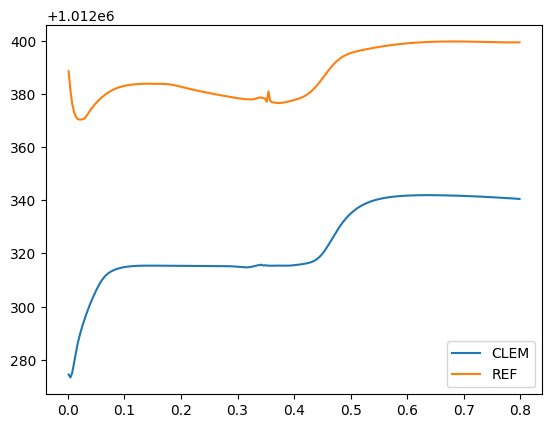

In [25]:
plt.plot(x_sim, p_sim[mask], label = "CLEM")
plt.plot(x_ref, p_ref[mask], label = "REF")
plt.legend()

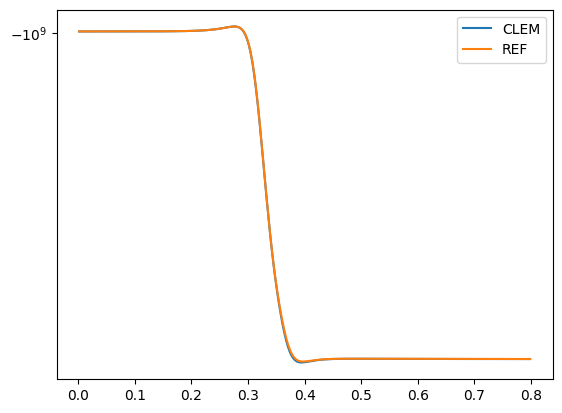

In [26]:
plt.plot(x_sim, rhoe_sim[mask]/rho_sim, label = "CLEM")
plt.plot(x_ref, rhoe_ref[mask]/rho_ref, label = "REF")
plt.legend()
plt.yscale("symlog")

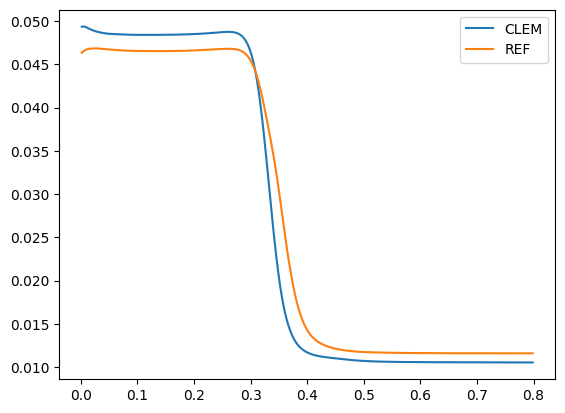

In [27]:
plt.plot(x_sim, xmom_sim[mask], label = "CLEM")
plt.plot(x_ref, xmom_ref[mask], label = "REF")
plt.legend()

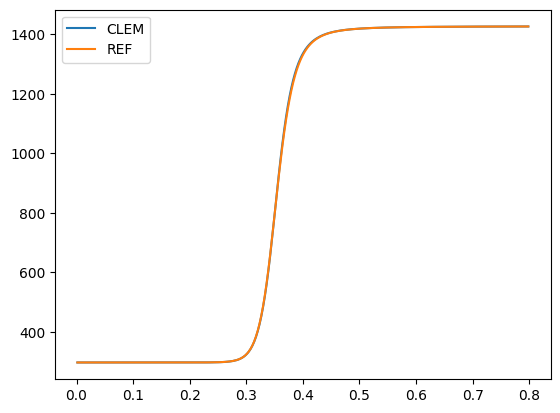

In [28]:
plt.plot(x_sim, temp_sim[mask], label = "CLEM")
plt.plot(x_ref, temp_ref[mask], label = "REF")
plt.legend()

Reference: /home/fernando/FPCE/PeleC/Exec/RegTests/1DFlame/ANALYSIS/pltREACT_01000
Simulation: RESULTS/pltREACT_CLEM_01000


'\nprint("\n" + "="*80)\nprint(f"Errors (sim − ref) in x ∈ [{X_MIN}, {X_MAX}] for step 01000")\nprint("="*80)\nprint(df_errors.to_string(index=False, float_format="%.6e"))\nprint("="*80)'

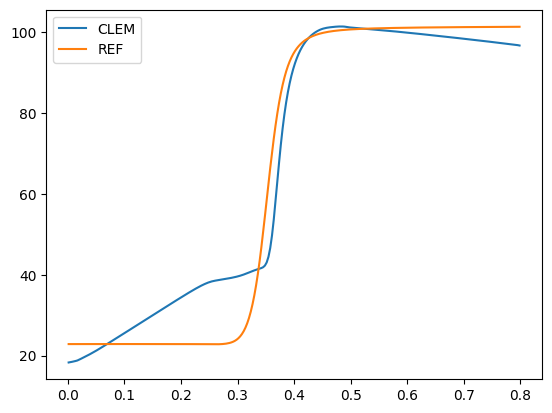

In [4]:
# ======================== CONFIGURATION ========================
root_reference = "/home/fernando/FPCE/PeleC/Exec/RegTests/1DFlame/ANALYSIS"
root_simulation = "RESULTS"
ref_file = "pltREACT_01000"
sim_file = "pltREACT_CLEM_01000"

X_MIN, X_MAX = 0.0, 1.5   # range of interest

# ======================== EXTRACTION FUNCTION ========================
def extract_fields(path):
    yt.set_log_level(50)
    ds = yt.load(path)
    c = ds.domain_center
    ray = ds.ortho_ray(0, (c[1], c[2]))
    order = np.argsort(ray["boxlib", "x"])
    
    x = np.array(ray["boxlib", "x"][order])
    density = np.array(ray["boxlib", "density"][order])
    xmom = np.array(ray["boxlib", "xmom"][order])
    velocity = np.array(ray["velocity_x"][order])
    pressure = np.array(ray["pressure"][order])
    temp = np.array(ray["Temp"][order])
    # pressure = np.array(ray["boxlib", "pressure"][order])  # if needed
    
    return x, density, xmom, velocity, pressure, temp

# ======================== LOAD & INTERPOLATE ========================
ref_path = os.path.join(root_reference, ref_file)
sim_path = os.path.join(root_simulation, sim_file)

print(f"Reference: {ref_path}")
print(f"Simulation: {sim_path}")

x_ref, rho_ref, xmom_ref, vel_ref, p_ref, temp_ref = extract_fields(ref_path)
x_sim, rho_sim, xmom_sim, vel_sim, p_sim, temp_sim = extract_fields(sim_path)

# Interpolate simulation onto the reference grid
rho_sim_interp = np.interp(x_ref, x_sim, rho_sim)
xmom_sim_interp = np.interp(x_ref, x_sim, xmom_sim)
vel_sim_interp = np.interp(x_ref, x_sim, vel_sim)

# ======================== FILTER X-RANGE ========================
mask = (x_ref >= X_MIN) & (x_ref <= X_MAX)
x_filtered = x_ref[mask]
rho_err = rho_sim_interp[mask] - rho_ref[mask]
xmom_err = xmom_sim_interp[mask] - xmom_ref[mask]
vel_err = vel_sim_interp[mask] - vel_ref[mask]

plt.plot(x_sim, vel_sim[mask], label = "CLEM")
plt.plot(x_ref, vel_ref[mask], label = "REF")
plt.legend()
# ======================== BUILD TABLE ========================
df_errors = pd.DataFrame({
    "x": x_filtered,
    "error_density": rho_err,
    "error_xmom": xmom_err,
    "error_velocity": vel_err
})

# ======================== PRINT ========================
"""
print("\n" + "="*80)
print(f"Errors (sim − ref) in x ∈ [{X_MIN}, {X_MAX}] for step 01000")
print("="*80)
print(df_errors.to_string(index=False, float_format="%.6e"))
print("="*80)"""

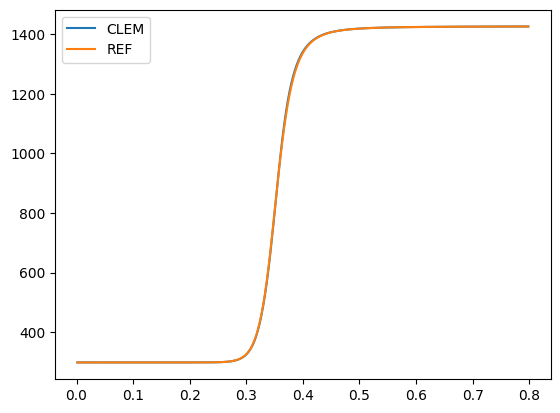

In [5]:
plt.plot(x_sim, temp_sim[mask], label = "CLEM")
plt.plot(x_ref, temp_ref[mask], label = "REF")
plt.legend()

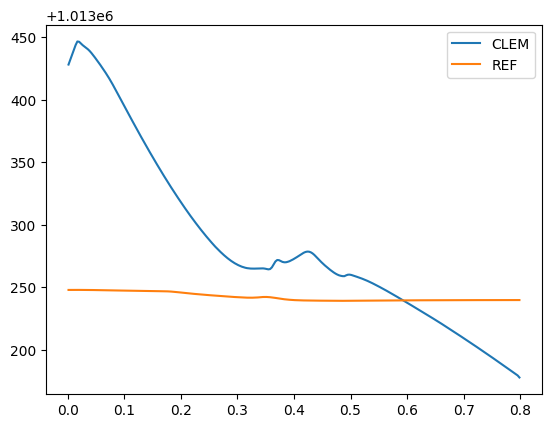

In [6]:
plt.plot(x_sim, p_sim[mask], label = "CLEM")
plt.plot(x_ref, p_ref[mask], label = "REF")
plt.legend()